In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
url = "https://www.data.gouv.fr/api/1/datasets/allergen-chip-challenge/"

In [2]:
# df_principal = pd.read_csv("../data/allergenchipchallenge-data-corrected-final-hdh-sfa (2).csv", sep=";")
# df_principal.head()

import pandas as pd
import sqlite3

# Dans le fichier BRUT, il y a 4,271 lignes. On a nettoyé ce fichier.
# Dans le fichier CLEAN, il y a 4,145 lignes.
db_path = "../data/allergen_chip_challenge.db"

# On va lire les données allergies directement depuis la table dans la base de données :
conn = sqlite3.connect(db_path)

df = pd.read_sql("Select * From allergies_categories", conn)
conn.close()
#on met close car ne se fait pas automatiquement
df.shape

(4145, 19)

In [3]:
# Affichage des 5 premières lignes dans le notebook pour vérification
print("Aperçu du nouveau tableau regroupé par catégories :")
display(df.head())

Aperçu du nouveau tableau regroupé par catégories :


,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,Region,Urban_area,Sensitization,Treatment_of_rhinitis,Treatment_of_asthma,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Acariens/Blattes,Aliments,Animaux,Moisissures/Autres,Pollens
0,FHB0001,ISAC_V1,20 à 40,1,11.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.43,0.00,0.00,0.0,0.00
1,FHB0002,ISAC_V1,40 à 60,0,12.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.00,77.91,0.00,0.0,168.54
2,FHB0003,ISAC_V1,0 à 20,1,1.0,regionB,0,0,Anti-H1 voie générale,0,Aucun,0,Acariens,Non renseigné,0.00,0.00,0.00,0.0,0.00
3,FHB0004,ISAC_V1,0 à 20,0,1.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,34.68,20.77,0.72,0.0,268.78
4,FHB0005,ISAC_V1,20 à 40,0,1.0,regionB,0,1,Non renseigné,0,Non renseigné,0,Aucun,Non renseigné,0.00,0.00,0.00,0.0,140.05


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

In [11]:
left_columns = []
all_cols = df.columns.tolist()

right_columns = []
for i in range(15, 19):
    right_columns.append(all_cols[i])

right_columns


# Taking columns from the left hand, but not the row-id neither the Patient_ID:
for i in range(1, 14):
    left_columns.append(all_cols[i])

left_columns

['Chip_Type',
 'Age',
 'Gender',
 'Blood_Month_sample',
 'Region',
 'Urban_area',
 'Sensitization',
 'Treatment_of_rhinitis',
 'Treatment_of_asthma',
 'Age_of_onsets',
 'Skin_Symptoms',
 'General_cofactors',
 'Treatment_of_atopic_dematitis']

In [12]:
# =====================================================================
# PARTIE A : Initiation au Machine Learning (Exemple avec Scikit-Learn)
# =====================================================================


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

col_that_need_dummies = ['Chip_Type', 'Age', 'Blood_Month_sample', 'Region', 'Treatment_of_rhinitis', 'Age_of_onsets', 'General_cofactors', 'Treatment_of_atopic_dematitis']

# We keep only the columns to keep, and (for the pure categorical columns) we make some dummies.
df2 = df[left_columns + right_columns]
df3 = pd.get_dummies(data=df2, columns=col_that_need_dummies)


# print("--- Préparation du Machine Learning ---")
# Pour faire du ML, on sépare généralement nos données :
# X = les colonnes qui servent à prédire (les indices)
# y = la colonne que l'on veut deviner (la cible)

# Définition des colonnes qui sont dans X, et de la colonne qui est dans y :
X = df3.drop(columns=["Sensitization"])
y = df3["Sensitization"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0) 
# pour que le hasard soit toujours le même => state = 0

# On peut centrer/réduire les données avec un SCALER :

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # centrer/réduire les données
scaler.set_output(transform="pandas")

# Transformation autant pour X_train que pour X_test :
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

# [Note : Ce code est un modèle théorique, il s'adaptera à tes vraies colonnes]
print("Étape 1 : Séparation des données en 'Entraînement' et 'Test'")
print("Étape 2 : Création du modèle (ex: RandomForestClassifier)")
print("Étape 3 : Entraînement du modèle avec la fonction .fit()")


Étape 1 : Séparation des données en 'Entraînement' et 'Test'
Étape 2 : Création du modèle (ex: RandomForestClassifier)
Étape 3 : Entraînement du modèle avec la fonction .fit()


In [13]:
# étape 2 (randomforest)"

from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()

rfc.fit(X=X_train, y=y_train)

score = rfc.score(X=X_test, y=y_test)

print(score)

0.8254580520732884


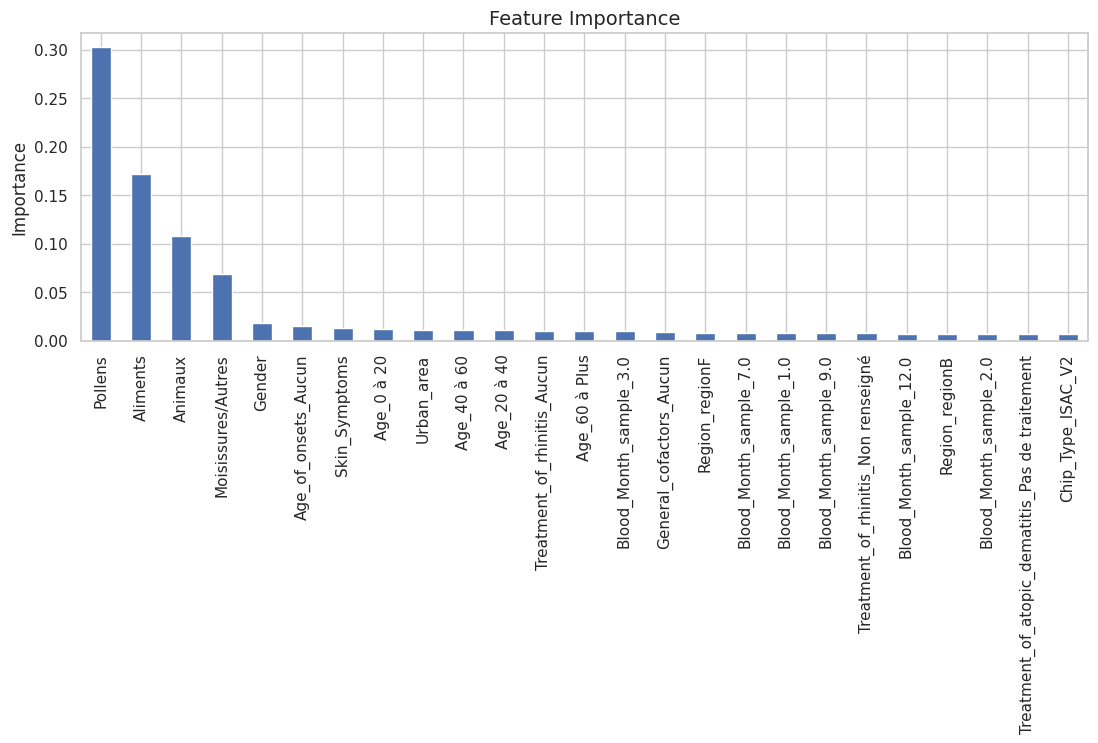

In [20]:
import matplotlib.pyplot as plt

importances = pd.Series(rfc.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

# Top 25
importances_z = importances[:25]

# Plot
plt.figure(figsize=(13, 4))
importances_z.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

In [ ]:
# PARTIE B : Exportation des données pour PowerBI
# =====================================================================
# Une fois que tout ton nettoyage et tes analyses sont finis dans VS Code,
# tu dois enregistrer ton tableau final en fichier CSV.

# nom_fichier_final = "donnees_pollens_propre.csv"
# df = nom_fichier_final

# La fonction .to_csv() crée un vrai fichier sur ton ordinateur
# f_final.to_csv(nom_fichier_final, index=False, sep=';', encoding='utf-8-sig')
# df.to_csv(nom_fichier_final, index=False, sep=';', encoding='utf-8-sig')

# print("\n--- Export PowerBI ---")
# print(f"Félicitations ! Le fichier '{nom_fichier_final}' a été créé.")
# print("Tu peux maintenant ouvrir PowerBI et charger ce fichier pour faire tes visuels.")


--- Export PowerBI ---
Félicitations ! Le fichier 'donnees_pollens_propre.csv' a été créé.
Tu peux maintenant ouvrir PowerBI et charger ce fichier pour faire tes visuels.


In [ ]:
# AUTRE EXEMPLE DE JOINTURE 

In [1]:
import pandas as pd

# Ton tableau principal (simulé ici avec une colonne 'Departement')
donnees_pollens = {
    'Nom_Allergene': ['Bet v 1', 'Phl p 1', 'Der p 1'],
    'Departement': [75, 69, 13],
    'Concentration': [45, 12, 80]
}
df_pollens = pd.DataFrame(donnees_pollens)

# Le nouveau tableau : Données météo publiques du jour
donnees_meteo = {
    'Departement': [13, 69, 75, 44],
    'Temperature_C': [22, 19, 15, 17],
    'Vitesse_Vent_kmh': [35, 10, 5, 20]
}
df_meteo = pd.DataFrame(donnees_meteo)

# LA JOINTURE : On fusionne les deux sur la colonne commune 'Departement'
df_complet = pd.merge(df_pollens, df_meteo, on='Departement', how='left')

print("--- Tableau après jointure météo ---")
df_complet.head()

--- Tableau après jointure météo ---


,Nom_Allergene,Departement,Concentration,Temperature_C,Vitesse_Vent_kmh
0,Bet v 1,75,45,15,5
1,Phl p 1,69,12,19,10
2,Der p 1,13,80,22,35


In [2]:
# KPI 1 : La concentration maximale de pollen enregistrée
kpi_max_pollen = df_complet['Concentration'].max()

# KPI 2 : Le taux moyen de vent sur nos stations
kpi_vent_moyen = df_complet['Vitesse_Vent_kmh'].mean()

# KPI 3 : Le nombre total d'allergènes différents analysés
kpi_nb_allergenes = df_complet['Nom_Allergene'].nunique()

print("--- Vos KPIs du jour ---")
print(f"🚨 Concentration Max de Pollen : {kpi_max_pollen} grains/m³")
print(f"💨 Vitesse moyenne du vent : {kpi_vent_moyen:.1f} km/h")
print(f"🔬 Nombre d'allergènes uniques : {kpi_nb_allergenes}")

--- Vos KPIs du jour ---
🚨 Concentration Max de Pollen : 80 grains/m³
💨 Vitesse moyenne du vent : 16.7 km/h
🔬 Nombre d'allergènes uniques : 3


/tmp/ipykernel_47434/2533915713.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_complet, x='Nom_Allergene', y='Concentration', palette='viridis')


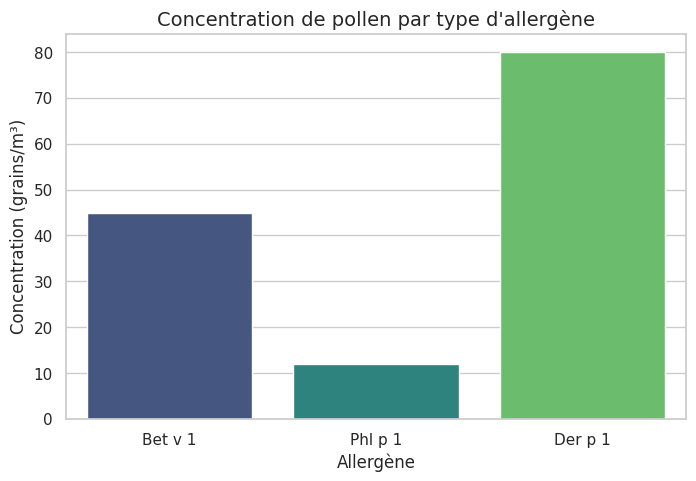

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# On configure le style du graphique
sns.set_theme(style="whitegrid")

# Création d'un graphique à barres : Concentration par Allergène
plt.figure(figsize=(8, 5))
sns.barplot(data=df_complet, x='Nom_Allergene', y='Concentration', palette='viridis')

# Ajout des titres
plt.title("Concentration de pollen par type d'allergène", fontsize=14)
plt.xlabel("Allergène", fontsize=12)
plt.ylabel("Concentration (grains/m³)", fontsize=12)

# Affichage du graphique dans VS Code
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. On prépare nos données de simulation
# X = les indices (température et vent), y = ce qu'on veut deviner (Risque Fort = 1, Faible = 0)
X = df_complet[['Temperature_C', 'Vitesse_Vent_kmh']]
y = [1, 0, 1]  # Simulation des étiquettes de risque pour l'exemple

# 2. Séparation des données (Entraînement 66% / Test 33%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# 3. Choix de l'algorithme (Forêt aléatoire)
modele = RandomForestClassifier(random_state=42)

# 4. ENTRAÎNEMENT : L'IA apprend les règles de cause à effet
modele.fit(X_train, y_train)

# 5. PRÉDICTION : On demande à l'IA de deviner sur les données de test
predictions = modele.predict(X_test)

# 6. ÉVALUATION : Est-ce que notre IA a eu juste ?
score = accuracy_score(y_test, predictions)
print(f"Précision du modèle de Machine Learning : {score * 100:.0f} %")

Précision du modèle de Machine Learning : 0 %


In [ ]:
# AUTRE exemple miniature mais complet du projet. Intégration des blocs dans le code pour faire des tests !

In [5]:
# 1. On imagine que ton df_pollens a une colonne 'Departement'
# 2. On charge les données météo (ici on simule un tableau, mais ça pourrait être un autre CSV)
import pandas as pd

donnees_meteo = {
    'Departement': [13, 69, 75, 44],
    'Temperature_C': [22, 19, 15, 17],
    'Vitesse_Vent_kmh': [35, 10, 5, 20]
}
df_meteo = pd.DataFrame(donnees_meteo)

# 3. La jointure : on fusionne tes pollens avec la météo
df_complet = pd.merge(df_pollens, df_meteo, on='Departement', how='left')
print("Jointure réussie ! Voici un aperçu :")
df_complet.head()

Jointure réussie ! Voici un aperçu :


,Nom_Allergene,Departement,Concentration,Temperature_C,Vitesse_Vent_kmh
0,Bet v 1,75,45,15,5
1,Phl p 1,69,12,19,10
2,Der p 1,13,80,22,35


In [6]:
# Remplace 'Concentration' par le vrai nom de ta colonne de scores de pollens
kpi_max_pollen = df_complet['Concentration'].max()
kpi_vent_moyen = df_complet['Vitesse_Vent_kmh'].mean()
kpi_total_analyses = len(df_complet)

print(f"🚨 Concentration Maximale détectée : {kpi_max_pollen} grains/m³")
print(f"💨 Vitesse moyenne du vent : {kpi_vent_moyen:.1f} km/h")
print(f"📊 Nombre total de prélèvements analysés : {kpi_total_analyses}")

🚨 Concentration Maximale détectée : 80 grains/m³
💨 Vitesse moyenne du vent : 16.7 km/h
📊 Nombre total de prélèvements analysés : 3


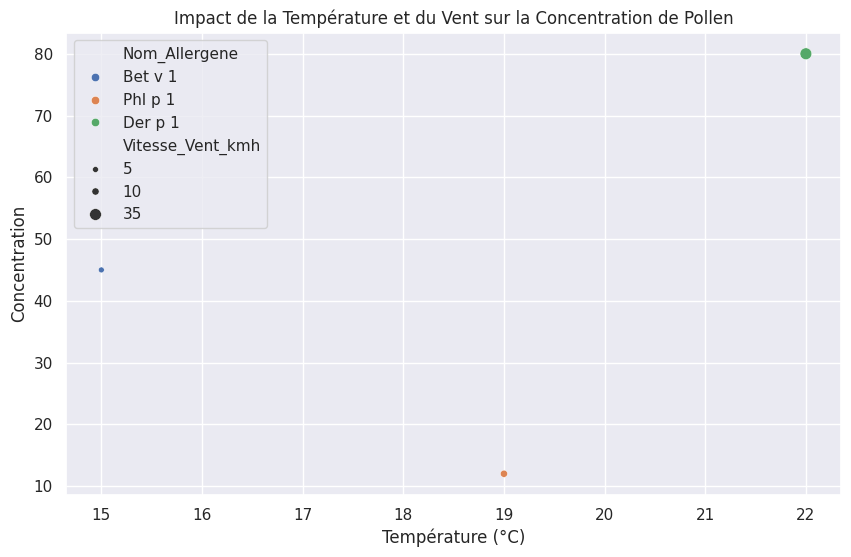

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# On définit le style
sns.set_theme(style="darkgrid")

# On crée un graphique : Température vs Concentration de Pollen
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_complet, x='Temperature_C', y='Concentration', hue='Nom_Allergene', size='Vitesse_Vent_kmh')

plt.title("Impact de la Température et du Vent sur la Concentration de Pollen")
plt.xlabel("Température (°C)")
plt.ylabel("Concentration")

# Cette ligne affiche le graphique directement sous ta cellule dans VS Code
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. On crée une colonne cible : Risque (1 si Concentration > 40, sinon 0)
df_complet['Risque_Eleve'] = (df_complet['Concentration'] > 40).astype(int)

# 2. Nos variables prédictives (X) et notre cible (y)
X = df_complet[['Temperature_C', 'Vitesse_Vent_kmh']]
y = df_complet['Risque_Eleve']

# 3. Séparation des données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Entraînement du modèle
modele = RandomForestClassifier()
modele.fit(X_train, y_train)

# 5. Score de précision
precision = modele.score(X_test, y_test)
print(f"Le modèle de Machine Learning a une précision de : {precision * 100:.1f}%")

Le modèle de Machine Learning a une précision de : 0.0%
